<a href="https://colab.research.google.com/github/zixian0821-zoe/stochastic_search_and_optimization/blob/main/hw9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Terminal normalized error means over 50 runs
FDSA semiautomatic: 0.43154847010663083
FDSA manual tuning: 0.5815497918382098
Random search B   : 1.3167319381677236


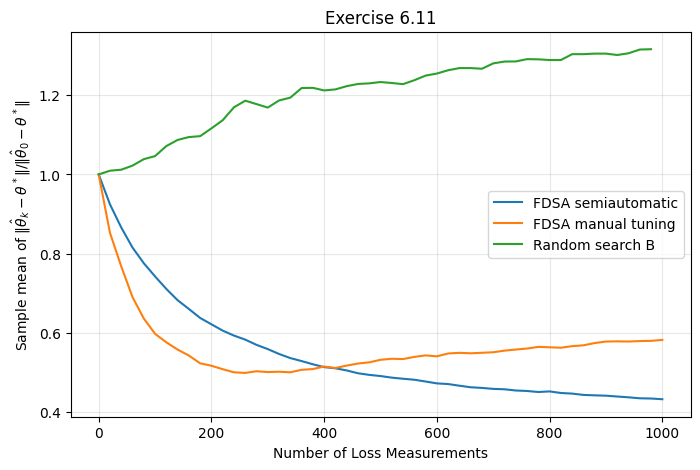

In [1]:
import numpy as np
import matplotlib.pyplot as plt


p = 10
theta_star = np.zeros(p)
theta0 = np.ones(p)
theta0_norm = np.linalg.norm(theta0 - theta_star)

B = np.triu(np.ones((p, p))) / p

def loss(theta):
    z = B @ theta
    return np.sum(z**2) + 0.1 * np.sum(z**3) + 0.01 * np.sum(z**4)

def noisy_loss(theta, rng):
    return loss(theta) + rng.normal(0.0, 1.0)

def project_box(theta, low=-5.0, high=5.0):
    return np.clip(theta, low, high)


def run_fdsa(a_num, A=5.0, c_num=1.0, alpha=0.602, gamma=0.101, seed=0):
    rng = np.random.default_rng(seed)
    theta = theta0.copy()
    traj = [np.linalg.norm(theta) / theta0_norm]

    n_measurements = 0
    k = 0

    while n_measurements < 1000:
        ak = a_num / ((k + 1 + A) ** alpha)
        ck = c_num / ((k + 1) ** gamma)

        ghat = np.zeros(p)

        for i in range(p):
            ei = np.zeros(p)
            ei[i] = 1.0

            y_plus = noisy_loss(theta + ck * ei, rng)
            y_minus = noisy_loss(theta - ck * ei, rng)

            ghat[i] = (y_plus - y_minus) / (2.0 * ck)
            n_measurements += 2

        theta = project_box(theta - ak * ghat)
        traj.append(np.linalg.norm(theta) / theta0_norm)
        k += 1

        if n_measurements >= 1000:
            break

    x_axis = np.arange(0, 1000 + 1, 20)
    return np.array(x_axis[:len(traj)]), np.array(traj), theta


def avg_noisy_loss(theta, rng, m=20):
    vals = [noisy_loss(theta, rng) for _ in range(m)]
    return np.mean(vals)

def run_random_search_B(seed=0):
    rng = np.random.default_rng(seed)
    theta = theta0.copy()
    traj = [np.linalg.norm(theta) / theta0_norm]

    current_val = avg_noisy_loss(theta, rng, m=20)
    n_measurements = 20

    while n_measurements + 20 <= 1000:
        d = rng.normal(0.0, 0.5, size=p)
        candidate = project_box(theta + d)
        cand_val = avg_noisy_loss(candidate, rng, m=20)
        n_measurements += 20

        if cand_val < current_val:
            theta = candidate
            current_val = cand_val

        traj.append(np.linalg.norm(theta) / theta0_norm)

    x_axis = np.arange(0, 1000 + 1, 20)
    return np.array(x_axis[:len(traj)]), np.array(traj), theta


n_runs = 50

fdsa_semi_curves = []
fdsa_manual_curves = []
rsb_curves = []

fdsa_semi_terminal = []
fdsa_manual_terminal = []
rsb_terminal = []

for r in range(n_runs):
    x1, y1, th1 = run_fdsa(a_num=0.25, seed=1000 + r)
    x2, y2, th2 = run_fdsa(a_num=0.50, seed=2000 + r)
    x3, y3, th3 = run_random_search_B(seed=3000 + r)

    fdsa_semi_curves.append(y1)
    fdsa_manual_curves.append(y2)
    rsb_curves.append(y3)

    fdsa_semi_terminal.append(np.linalg.norm(th1) / theta0_norm)
    fdsa_manual_terminal.append(np.linalg.norm(th2) / theta0_norm)
    rsb_terminal.append(np.linalg.norm(th3) / theta0_norm)

fdsa_semi_curves = np.vstack(fdsa_semi_curves)
fdsa_manual_curves = np.vstack(fdsa_manual_curves)
rsb_curves = np.vstack(rsb_curves)

fdsa_semi_mean = fdsa_semi_curves.mean(axis=0)
fdsa_manual_mean = fdsa_manual_curves.mean(axis=0)
rsb_mean = rsb_curves.mean(axis=0)

print("Terminal normalized error means over 50 runs")
print("FDSA semiautomatic:", np.mean(fdsa_semi_terminal))
print("FDSA manual tuning:", np.mean(fdsa_manual_terminal))
print("Random search B   :", np.mean(rsb_terminal))

plt.figure(figsize=(8, 5))
plt.plot(x1, fdsa_semi_mean, label="FDSA semiautomatic")
plt.plot(x2, fdsa_manual_mean, label="FDSA manual tuning")
plt.plot(x3, rsb_mean, label="Random search B")
plt.xlabel("Number of Loss Measurements")
plt.ylabel(r"Sample mean of $\|\hat{\theta}_k-\theta^*\|/\|\hat{\theta}_0-\theta^*\|$")
plt.title("Exercise 6.11")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Distribution: bernoulli
  iterations completed: 1000
  final loss: 3.144507e-02
  final ||theta||: 1.801814e+00

Distribution: uniform
  iterations completed: 1000
  final loss: 1.568644e+63
  final ||theta||: 1.241491e+17

Distribution: normal
  iterations completed: 1000
  final loss: 6.139529e+156
  final ||theta||: 2.378140e+40



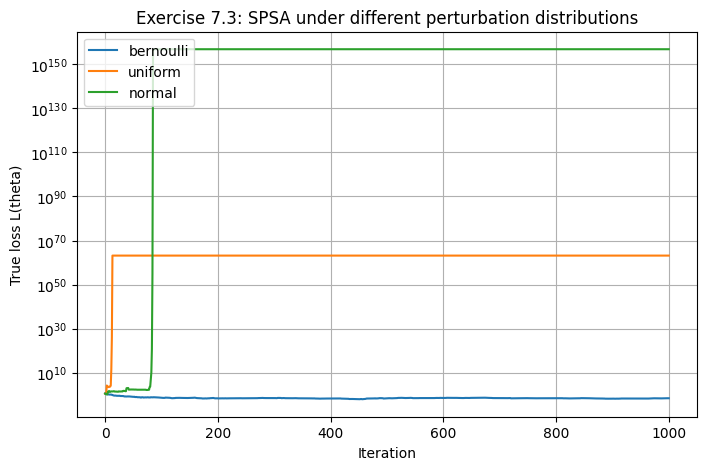

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

p = 10
a = 0.5
A = 50
c = 0.1
alpha = 0.602
gamma = 0.101
sigma = 0.1
theta0 = np.ones(p)
n_measurements = 2000
n_iters = n_measurements // 2

U = np.triu(np.ones((p, p)))
B = U / p

def loss(theta):
    z = B @ theta
    return theta @ (B.T @ B) @ theta + 0.1 * np.sum(z ** 3) + 0.01 * np.sum(z ** 4)

def noisy_loss(theta):
    return loss(theta) + np.random.normal(0, sigma)

def sample_delta(dist, p):
    if dist == "bernoulli":
        return np.random.choice([-1.0, 1.0], size=p)
    elif dist == "uniform":
        return np.random.uniform(-np.sqrt(3), np.sqrt(3), size=p)
    elif dist == "normal":
        return np.random.normal(0.0, 1.0, size=p)
    else:
        raise ValueError("Unknown distribution")

def spsa_run(dist, seed=None):
    if seed is not None:
        np.random.seed(seed)

    theta = theta0.copy()
    loss_hist = [loss(theta)]
    theta_hist = [theta.copy()]

    for k in range(n_iters):
        ak = a / ((k + 1 + A) ** alpha)
        ck = c / ((k + 1) ** gamma)

        delta = sample_delta(dist, p)

        y_plus = noisy_loss(theta + ck * delta)
        y_minus = noisy_loss(theta - ck * delta)

        ghat = (y_plus - y_minus) / (2.0 * ck * delta)
        theta = theta - ak * ghat

        loss_hist.append(loss(theta))
        theta_hist.append(theta.copy())

        if not np.all(np.isfinite(theta)) or not np.isfinite(loss_hist[-1]):
            break

    return np.array(loss_hist), np.array(theta_hist)

results = {}
for dist in ["bernoulli", "uniform", "normal"]:
    loss_hist, theta_hist = spsa_run(dist)
    results[dist] = {
        "loss_hist": loss_hist,
        "theta_hist": theta_hist,
        "final_loss": loss_hist[-1],
        "final_theta_norm": np.linalg.norm(theta_hist[-1]),
        "n_iters_completed": len(loss_hist) - 1
    }

for dist in results:
    print(f"Distribution: {dist}")
    print(f"  iterations completed: {results[dist]['n_iters_completed']}")
    print(f"  final loss: {results[dist]['final_loss']:.6e}")
    print(f"  final ||theta||: {results[dist]['final_theta_norm']:.6e}")
    print()

plt.figure(figsize=(8, 5))
for dist in results:
    plt.plot(results[dist]["loss_hist"], label=dist)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("True loss L(theta)")
plt.title("Exercise 7.3: SPSA under different perturbation distributions")
plt.legend()
plt.grid(True)
plt.show()

Best c: 3.50
Mean terminal loss at best c: 0.358932
Rule-of-thumb c (noise sd): 2.00


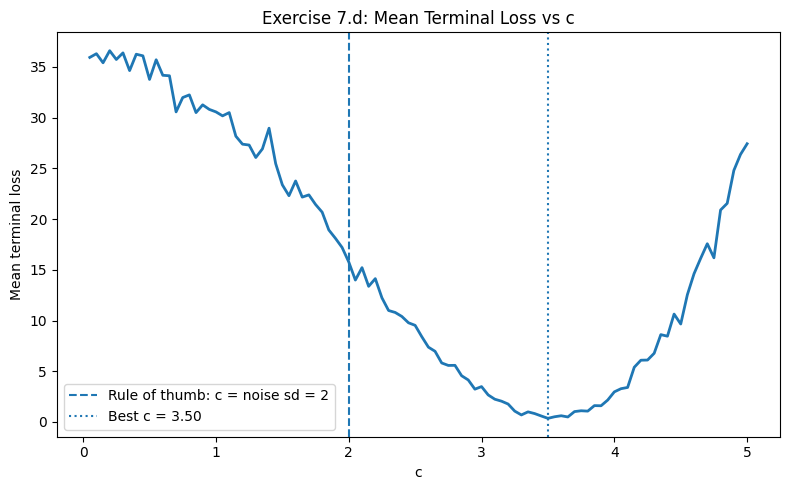

In [2]:
import numpy as np
import matplotlib.pyplot as plt


p = 10
theta0 = np.full(p, 6.0)
alpha = 0.602
gamma = 0.101
A = 50.0
a = 0.0016

noise_sd = 2.0
n_measurements = 1000
n_iterations = n_measurements // 2
n_reps = 40

c_values = np.arange(0.05, 5.00 + 1e-12, 0.05)

rng = np.random.default_rng(20260331)


def loss(theta):
    return ((theta @ theta) / 5.0 - 25.0) ** 2

def noisy_loss(theta, rng):
    return loss(theta) + rng.normal(0.0, noise_sd)


def run_spsa(c, seed=None):
    local_rng = np.random.default_rng(seed)
    theta = theta0.copy()

    for k in range(n_iterations):
        ak = a / ((k + 1 + A) ** alpha)
        ck = c / ((k + 1) ** gamma)

        delta = local_rng.choice([-1.0, 1.0], size=p)

        y_plus = noisy_loss(theta + ck * delta, local_rng)
        y_minus = noisy_loss(theta - ck * delta, local_rng)

        ghat = (y_plus - y_minus) / (2.0 * ck * delta)
        theta = theta - ak * ghat

    return loss(theta)


mean_terminal_losses = []
std_terminal_losses = []

for c in c_values:
    terminal_losses = []
    for rep in range(n_reps):
        seed = 100000 + int(round(c * 1000)) * 100 + rep
        terminal_losses.append(run_spsa(c, seed=seed))
    terminal_losses = np.array(terminal_losses)

    mean_terminal_losses.append(terminal_losses.mean())
    std_terminal_losses.append(terminal_losses.std(ddof=1))

mean_terminal_losses = np.array(mean_terminal_losses)
std_terminal_losses = np.array(std_terminal_losses)

best_idx = np.argmin(mean_terminal_losses)
best_c = c_values[best_idx]
best_mean_loss = mean_terminal_losses[best_idx]

print(f"Best c: {best_c:.2f}")
print(f"Mean terminal loss at best c: {best_mean_loss:.6f}")
print(f"Rule-of-thumb c (noise sd): {noise_sd:.2f}")


plt.figure(figsize=(8, 5))
plt.plot(c_values, mean_terminal_losses, linewidth=2)
plt.axvline(noise_sd, linestyle='--', linewidth=1.5, label='Rule of thumb: c = noise sd = 2')
plt.axvline(best_c, linestyle=':', linewidth=1.5, label=f'Best c = {best_c:.2f}')
plt.xlabel('c')
plt.ylabel('Mean terminal loss')
plt.title('Exercise 7.d: Mean Terminal Loss vs c')
plt.legend()
plt.tight_layout()
plt.show()